<a href="https://colab.research.google.com/github/Sj-kronton/IA_2025/blob/main/Ejercicio_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score #¿Cuanto vale una casa de 4 habitaciones?

In [3]:
df=pd.read_csv("/content/housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [31]:
df.sample()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20055,-119.12,35.85,37.0,736.0,166.0,564.0,138.0,2.4167,58300.0,INLAND


In [32]:
df.tail()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [9]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [10]:
total=df.isnull().sum().sort_values(ascending=False)
total


,0
total_bedrooms,207
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [11]:
percent=(df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
percent

,0
total_bedrooms,0.010029
longitude,0.000000
latitude,0.000000
housing_median_age,0.000000
total_rooms,0.000000
population,0.000000
households,0.000000
median_income,0.000000
median_house_value,0.000000
ocean_proximity,0.000000


In [12]:
def bar_char(feature):
  survived=df[df['Survived']==1][feature].value_counts()
  dead=df[df['Survived']==0][feature].value_counts()
  test=pd.DataFrame([survived,dead])
  test.index=['Sobrevivientes','Fallecidos']
  test.plot(kind='bar',stacked=True,figsize=(10,5))

In [28]:
data=pd.dataset(df)
data.head()

AttributeError: module 'pandas' has no attribute 'dataset'

/tmp/ipython-input-3102193799.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


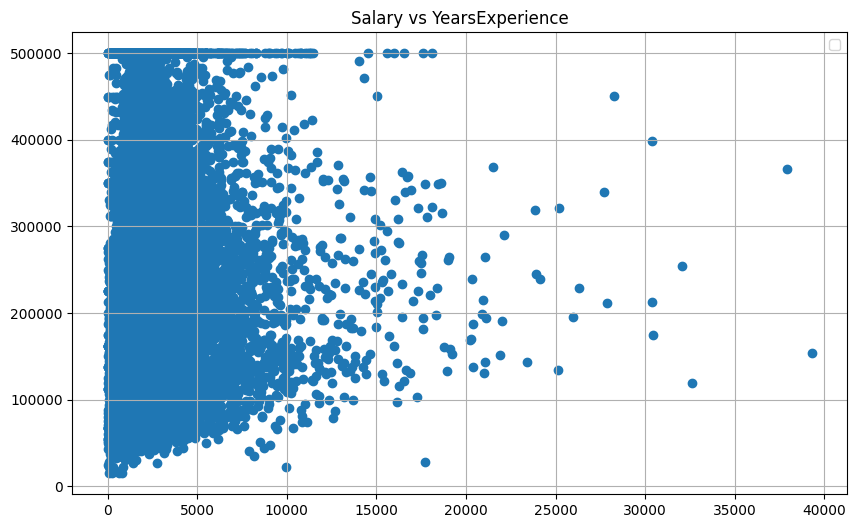

In [24]:
x=df["total_rooms"] #variables dependientes e independientes
y=df["median_house_value"]#esta es la dependiente

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.title("Salary vs YearsExperience")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-3098523835.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


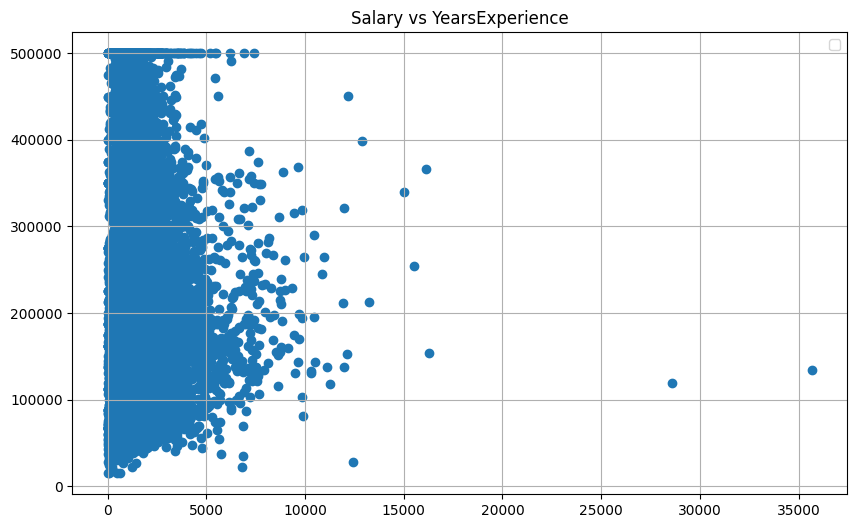

In [25]:
x=df["population"] #variables dependientes e independientes
y=df["median_house_value"]#esta es la dependiente

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.title("Salary vs YearsExperience")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-1972028870.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


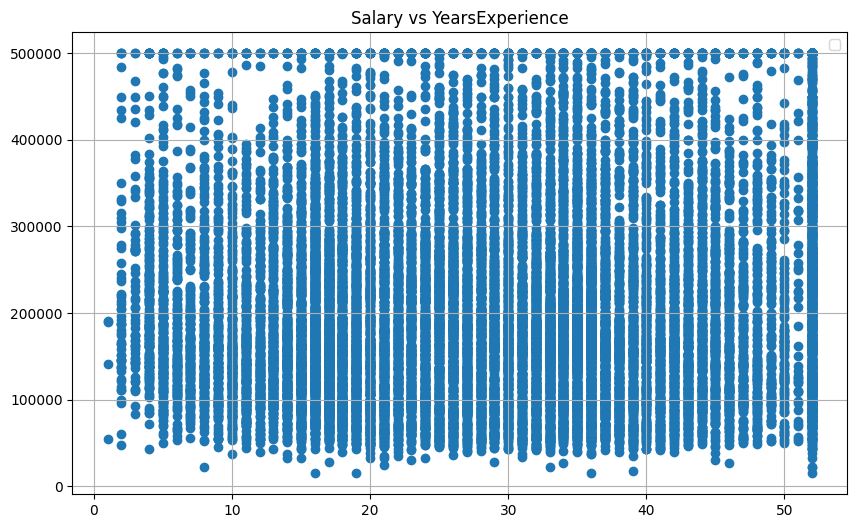

In [26]:
x=df["housing_median_age"] #variables dependientes e independientes
y=df["median_house_value"]#esta es la dependiente

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.title("Salary vs YearsExperience")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
df['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [37]:
# Crear un diccionario de mapeo de los valores de texto a números
mapeo_ocean_proximity = {
    '<1H OCEAN': 0,
    'INLAND': 3,
    'NEAR OCEAN': 2,
    'NEAR BAY': 1,
    'ISLAND': 4
}

# Aplicar el mapeo a la columna 'ocean_proximity'
df['ocean_proximity_encoded'] = df['ocean_proximity'].map(mapeo_ocean_proximity)

# Mostrar las primeras filas con la nueva columna codificada
display(df[['ocean_proximity', 'ocean_proximity_encoded']].head())

,ocean_proximity,ocean_proximity_encoded
0,NEAR BAY,1
1,NEAR BAY,1
2,NEAR BAY,1
3,NEAR BAY,1
4,NEAR BAY,1


In [38]:
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,ocean_proximity_encoded
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,1


/tmp/ipython-input-3990796482.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


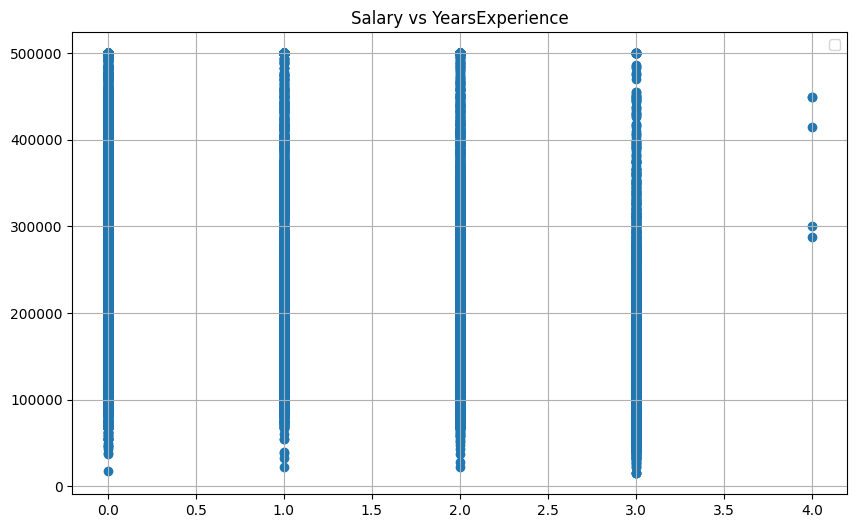

In [39]:
x=df["ocean_proximity_encoded"] #variables dependientes e independientes
y=df["median_house_value"]#esta es la dependiente

plt.figure(figsize=(10,6))
plt.scatter(x,y)
plt.title("Salary vs YearsExperience")
plt.legend()
plt.grid(True)
plt.show()

In [51]:

x = df[['total_rooms']] #variable independiente
y = df['median_house_value'] #variable dependiente

#ajustar datos al modelo de regresion lineal
model = LinearRegression()
model.fit(x, y)

#generar las predicciones
y_pred = model.predict(x)

#hallar el R2
r2 = r2_score(y, y_pred)

print(f"El coeficiente de determinación R cuadrado es: {r2}")

El coeficiente de determinación R cuadrado es: 0.017997057943996753


In [50]:
total_rooms_input = np.array([[4]])
predicted_median_house_value = model.predict(total_rooms_input)

print(f"El valor estimado de median_house_value para una casa con 4 habitaciones es: {predicted_median_house_value[0]}")

El valor estimado de median_house_value para una casa con 4 habitaciones es: 188180.89923084417


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [59]:
#filtrar el DataFrame para incluir solo las filas donde total_rooms <= 4
df_filtered = df[df['total_rooms'] <= 4].copy()

x_filtered = df_filtered[['total_rooms']] #variable independiente
y_filtered = df_filtered['median_house_value'] #variable dependiente

#ajustar datos al modelo de regresion lineal
model_filtered = LinearRegression()
model_filtered.fit(x_filtered, y_filtered)

#predicciones
y_pred_filtered = model_filtered.predict(x_filtered)

#EL R^2
r2_filteredto = r2_score(y_filtered, y_pred_filtered)

print(f"El coeficiente de determinación R cuadrado (para total_rooms <= 4) es: {r2_filteredto}") #solo hay un unica fila donde total_rooms tiene un valor menor a 4, entonces no se puede calcular un R^2

#calcular ahora cuando valdria una casa de 4 rooms con el Dataframe cortado a que evalue solo filas de 4 o menos rooms
total_rooms_input = np.array([[4]])
predicted_median_house_value_filtered = model_filtered.predict(total_rooms_input)
print(f"El valorg estimado de cuanto vale una casa si tiene con 4 habitaciones (usando datos con total_rooms <= 4) es: {predicted_median_house_value_filtered[0]}")

El coeficiente de determinación R cuadrado (para total_rooms <= 4) es: nan
El valorg estimado de cuanto vale una casa si tiene con 4 habitaciones (usando datos con total_rooms <= 4) es: 137500.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
